前面学习了如何使用Sklearn中的机器学习算法解决回归和分类问题。回归和分类是有监督学习的典型代表。接下来我们继续学习数据聚类算法。聚类算法是无监督学习的算法，训练数据没有被标记。相反，算法根据共同特征对数据集进行聚类或分组。我们介绍两种最常见的聚类算法，即K均值聚类和层次聚类。
K均值聚类是聚类未标记数据最常用的算法之一。在K均值聚类中，K是指希望将数据分组到的聚类数。在K均值聚类中，必须先定义聚类的数量，然后才能将K聚类应用于数据点。以下是执行K均值聚类所需的一般步骤。

1. 为每个集群随机分配质心值。
2. 计算每个数据点与所有聚类的质心值之间的距离（欧几里得距离或曼哈顿距离）。
3. 将数据点分配给距离较短的质心簇。
4. 根据对应簇的所有数据点坐标的平均值计算和更新质心值。
5. 重复步骤 2-4，直到所有簇的新质心值与之前的质心值不同。

K均值聚类具有以下优点：

1. K均值聚类是一种实现简单的算法
2. 可应用于大型数据集
3. 可以很好地扩展到看不见的数据点
4. 很好地泛化到各种大小和形状的集群。

K均值聚类算法的缺点：

1. K的值必须手动选择
2. 收敛或训练时间取决于K的初始值
3. 聚类性能受异常值影响很大。

首先导入需要的库：

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets._samples_generator import make_blobs
from sklearn.cluster import KMeans
from matplotlib import pyplot as plt
%matplotlib inline

接下来，创建一个包含500条记录和4个聚类中心的虚拟数据集。记录之间的平均标准差为2.0。我们同时用点图将这些数据绘制出来：

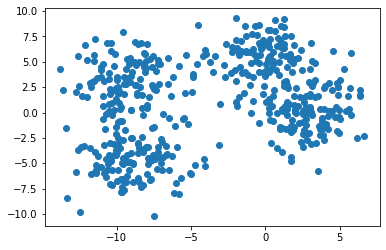

In [4]:
#创建一个包含500条记录和4个聚类中心的虚拟数据集
features, labels = make_blobs(n_samples=500, centers=4, cluster_std = 2.00)
plt.scatter(features[:,0], features[:,1] )

虚拟数据是随机生成的，因此，每次重新运行程序得到的数据都是不同的。要实现K均值聚类，可以使用 sklearn.cluster模块中的KMeans 类。 需要将集群的数量作为属性传递给KMeans类的构造函数。要训练KMeans模型，只需将数据集传递给KMeans类的fit()方法：

In [6]:
# 使用KMeans类进行K均值聚类
km_model = KMeans(n_clusters = 4)
km_model.fit(features)

KMeans(n_clusters=4)

模型训练好了之后，可以使用KMeans类的cluster_centers_属性输出聚类的中心：

In [7]:
print(km_model.cluster_centers_)

[[-9.30848254  3.28795134]
 [ 2.73192846  0.0404208 ]
 [-0.21374709  5.66231244]
 [-8.87679918 -4.58359893]]


除了寻找聚类中心之外，KMeans类还为每个数据点分配了一个聚类标签。标签就是一个数字，代表了每一个集群的ID。例如，在四个集群的情况下，集群ID为 0、1、2、3。可以使用KMeans类的labels_属性输出标签的值：

In [8]:
print(km_model.labels_)

[0 0 2 3 3 3 2 1 2 3 1 3 0 2 0 3 1 0 1 3 3 3 3 2 2 0 1 1 3 0 1 1 0 3 1 3 3
 0 2 1 0 2 0 1 0 0 0 2 2 0 0 2 2 0 2 1 0 1 2 3 0 3 0 3 2 0 0 2 1 0 2 3 3 2
 0 0 2 1 1 0 3 3 1 3 2 3 0 3 1 2 1 2 2 1 0 1 0 3 1 0 3 1 3 0 1 3 2 3 0 1 1
 1 2 3 3 2 0 1 3 0 1 3 3 1 3 0 1 3 1 0 1 1 1 0 0 2 3 1 3 2 1 3 1 0 2 3 0 2
 0 2 2 0 2 2 1 2 3 0 1 0 2 2 2 1 0 2 1 3 1 3 2 3 3 1 1 2 0 3 2 3 0 0 3 2 0
 3 2 2 0 2 2 1 1 2 2 2 3 3 2 2 1 0 2 0 0 2 2 0 0 3 1 1 3 1 1 3 0 2 0 1 0 0
 2 2 3 2 0 1 3 2 3 2 3 3 0 2 2 3 3 0 0 1 0 0 2 3 3 0 1 0 0 0 1 2 2 0 3 1 2
 0 0 3 2 2 0 1 3 1 1 0 2 1 1 2 0 3 2 1 2 0 1 0 0 1 0 2 1 1 0 2 3 1 2 3 1 1
 1 3 1 1 1 3 1 3 2 0 1 0 3 3 0 1 3 2 1 3 1 2 1 2 1 1 2 0 1 3 3 0 3 2 0 2 0
 0 3 0 2 1 1 2 3 3 3 0 0 1 1 0 3 2 0 3 3 1 0 2 0 2 2 2 0 2 3 0 1 3 3 3 1 2
 0 0 1 0 1 0 0 0 0 1 2 3 1 1 2 1 1 1 3 3 3 0 1 1 2 0 3 1 1 2 3 0 2 1 3 3 1
 3 0 3 3 3 3 3 2 3 1 2 0 1 0 2 3 2 2 1 2 2 2 0 3 0 3 3 1 3 3 3 3 3 1 0 3 1
 3 1 3 3 1 1 1 1 1 1 1 3 2 1 2 3 2 2 3 2 2 1 1 0 0 1 1 2 3 2 3 3 3 2 1 2 1
 0 2 0 2 3 2 1 1 1 2 1 3 

为了直观显示，也可以用不同的颜色将4个类的点画出来，中心质点用黑色表示： 

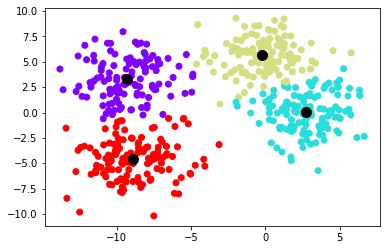

In [9]:
plt.scatter(features[:, 0], features[:, 1], c=km_model.labels_, cmap='rainbow')
plt.scatter(km_model.cluster_centers_[:, 0], km_model.cluster_centers_[:, 1], s=100, c='black')

作为测试，在一开始产生数据的时候，其实每个数据点就是有标签的。我们可以对比一下实际数据的情况：

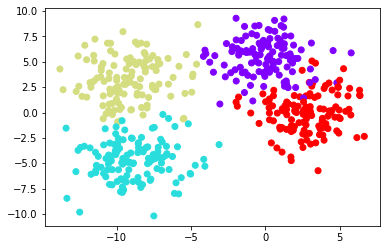

In [10]:
plt.scatter(features[:,0], features[:,1], c= labels, cmap='rainbow' )

接下来，我们使用前面已经很熟悉的iris鸢尾花数据集再做一次聚类的分析。

In [3]:
iris = pd.read_csv(r"..\DataSet\iris_data.csv")

由于是无监督的聚类分析，所以在训练模型的时候是不需要标签数据的，只需要特征值。我们将特征值和标签分开：

In [4]:
features = iris.drop(["species"], axis=1)
labels = iris.filter(["species"], axis=1)
features.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


我们已经知道，在使用KMeans聚类的时候，建立模型时需要指定聚类的个数。虽然，我们知道鸢尾花数据集的分类数是3，即数据集里包含了3中不同种类的鸢尾花。但在实际的聚类分析中，这个类别的个数一般是未知的。我们可以通过多次的实验来找出一个较好的分类。再此处，我们先猜测有4类不同的鸢尾花，类别参数指定为4来训练模型：

In [5]:
features = features.values
km_model = KMeans(n_clusters=4)
km_model.fit(features)

KMeans(n_clusters=4)

输出150朵花的全部分类：

In [6]:
print(km_model.labels_)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 3 3 3 2 3 2 3 2 3 2 2 2 2 3 2 3 3 2 3 2 3 2 3 3
 3 3 3 3 3 2 2 2 2 3 2 3 3 3 2 2 2 3 2 2 2 2 2 3 2 2 0 3 0 0 0 0 2 0 0 0 3
 3 0 3 3 0 0 0 0 3 0 3 0 3 0 0 3 3 0 0 0 0 0 3 3 0 0 0 3 0 0 0 3 0 0 0 3 3
 0 3]


也可以用4种颜色画出散点图，特征值取前2项，即sepal_length和sepal_width，以及后两项分别绘图：

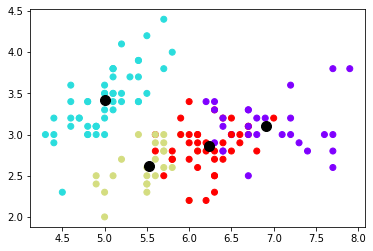

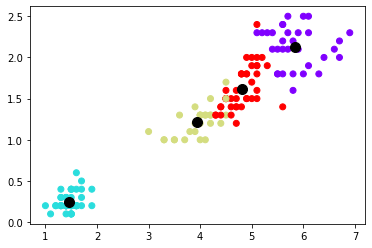

In [12]:
plt.scatter(features[:, 0], features[:, 1], c=km_model.labels_, cmap="rainbow")
# 输出聚类的中心点
plt.scatter(km_model.cluster_centers_[:, 0], km_model.cluster_centers_[:, 1], s=100, c="black")
plt.show()
plt.scatter(features[:, 2], features[:, 3], c=km_model.labels_, cmap="rainbow")
plt.scatter(km_model.cluster_centers_[:, 2], km_model.cluster_centers_[:, 3], s=100, c="black")

到目前为止，我们一直在随机初始化K的值或簇数。 但是，有一种方法可以找到理想的分类数量。 该方法称为elbow method。 我们知道k-means是以最小化样本与中心点平方误差作为目标函数，定义每个簇的中心点与簇内样本点的平方距离误差和为畸变程度(distortions)。那么，对于一个簇，它的畸变程度越低，代表簇内成员越紧密，畸变程度越高，代表簇内结构越松散。畸变程度会随着类别的增加而降低，但对于有一定区分度的数据，在达到某个临界点时畸变程度会得到极大改善，之后缓慢下降，这个临界点就可以考虑为聚类性能较好的点。其图像像一个胳膊肘，故名为elbow method。以下脚本创建K=1到10的distortions值，并以线图的形式绘制，如下所示：

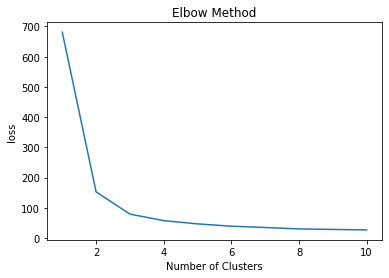

In [13]:
# training KMeans on K values from 1 to 10
loss = []
for i in range(1, 11):
    km = KMeans(n_clusters=i).fit(features)
    loss.append(km.inertia_)

# printing loss against number of clusters
plt.plot(range(1, 11), loss)
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('loss')
plt.show()


从上面的数据看到，分类数达到3之后，下降开始缓慢。接下来，我们使用K=3再一次训练模型：

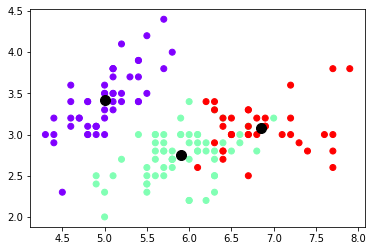

In [15]:
km_model = KMeans(n_clusters=3)
km_model.fit(features)

plt.scatter(features[:, 0], features[:, 1], c=km_model.labels_, cmap='rainbow')
plt.scatter(km_model.cluster_centers_[:, 0], km_model.cluster_centers_[:, 1], s=100, c='black')

对于iris数据集，我们是有原数据集的分类结果的，我们把原来数据也用不同颜色画出来，可以比较一下分类的效果：

c:\Users\cuish\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\preprocessing\_label.py:115: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


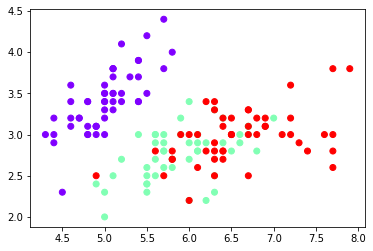

In [16]:
from sklearn import preprocessing
le = preprocessing.LabelEncoder()
labels = le.fit_transform(labels)
plt.scatter(features[:,0], features[:,1], c= labels, cmap='rainbow')

与K均值聚类一样，层次聚类是另一种常用的无监督机器学习技术。层次聚类可以大致分为两种类型：凝聚聚类和分裂聚类。凝聚聚类遵循自下而上的方法，单个数据点聚集在一起形成多个小聚类，小聚类再合并形成一个大聚类。在合并的过程中，会形成树状图，每个数据点是树状图的最底层-叶子，最后形成的最大的类是树的根。另一方面，在分裂聚类的情况下，一开始，所有数据是一个大聚类，然后逐步将其划分为N个小聚类。层次凝聚聚类的步骤如下：

1. 将数据集中的每个数据点视为一个集群。因此，一开始的簇数等于数据点的数量。
2. 加入两个最近的数据点形成一个簇。
3. 通过加入最近的集群形成更多的集群。重复这个过程，直到形成一个大簇。
4. 使用树状图将一个大簇划分为多个小簇。

层次聚类具有以下优点：

1. 与K均值聚类不同，对于层次聚类，您不必指定质心聚类的数量。
2. 使用树状图，更容易解释数据是如何聚类的。

层次聚类算法的缺点：

1. 在未知数据上不能很好地扩展。
2. 与K Means聚类相比具有更高的时间复杂度。
3. 大数据集的情况下很难确定簇的数量。

为了理解层次聚类，我们从一个小的例子开始，首先生成一个只含有10个数据以及2个簇的虚拟数据集，为了观察聚类的过程，我们将这10个数据点用1-10个整数标记了出来：

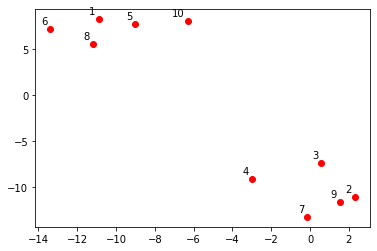

In [26]:
features, labels = make_blobs(n_samples=10, centers=2, cluster_std=2.00)
plt.scatter(features[:, 0], features[:, 1], color='r')
#对数据点做标记（1-10）并画图
annots = range(1, 11)
for label, x, y in zip(annots, features[:, 0], features[:, 1]):
    plt.annotate(label, xy=(x, y), xytext=(-3, 3), textcoords='offset points', ha='right', va='bottom')
plt.show()


下面我们为为上述10个数据点绘制树状图。要绘制树状图，可以使用 scipy.cluster.hierarchy 模块中的树状图和链接类。这些特征被传递给链接类。并将链接类的对象传递给树状图类以绘制特征的树状图，如下面的代码所示：

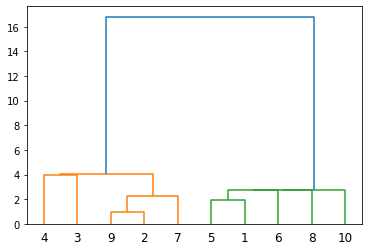

In [27]:
from scipy.cluster.hierarchy import dendrogram, linkage
dendos = linkage(features, 'single')
annots = range(1, 11)
dendrogram(dendos, orientation='top', labels=annots, distance_sort='descending', show_leaf_counts=True)
plt.show()

我们看到，3和4、2和9、1和5形成了一开始的小簇，随后一步步合并扩大，直到所有的数据形成一个大簇。注意数据是随机产生的，因此每次运行的结果都是有差异的。形成的树状图之后，我们可以选择最长的垂直线（或者说最靠近树的根部）将其分成若干子树。子树的数目就是分类的个数。也可以从更低的层次上（更加远离树根）将其分为更多的类（子树）。由于树状图已经形成，所有可以从任意层次上分割，产生需要的类别数。在实际应用中，可能有数千个数据点，因此不能使用树状图方法对数据直观的手动聚类。 这时可以使用 sklearn.cluster 模块中的 AgglomerativeClustering 类，簇的数量和距离类型作为参数传递给 AgglomerativeClustering 类来完成分割。
接下来，我们再一次载入iris数据集，使用分层的方法进行聚类：

In [3]:
iris = pd.read_csv(r"..\DataSet\iris_data.csv")
features = iris.drop(["species"], axis=1)
labels = iris.filter(["species"], axis=1)

随后我们使用凝聚层次模型进行聚类。以下是构造模型的代码：

In [4]:
from sklearn.cluster import AgglomerativeClustering
features = features.values
hc_model = AgglomerativeClustering(n_clusters=3, affinity='euclidean', linkage='ward')
hc_model.fit_predict(features)

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 0, 2, 2, 2, 2,
       2, 0, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0], dtype=int64)

在上面的代码中，主要调用了AgglomerativeClustering进行层次聚类。构造模型的时候传递了3个参数：第一个参数n_clusters是聚类的个数，affinity参数指出了计算2个数据点之间的距离时采用的算法。当传递的值为“euclidean”表示采用欧⽒距离计算，“manhattan”表示曼哈顿距离，“cosine”表示余弦距离等。第3个参数linkage表示链接的方法。也就是说，当距离计算出来了以后，通过什么准则判定数据点是同意一别的。linkage的参数选择一共有4个：{“ward”, “complete”, “average”, “single”}, 

+ ward使得合并的类方差最小化
+ average：组间距离等于两组对象之间的平均距离（计算量比较大）
+ complete：组间距离等于两组对象之间的最大距离（两个不相似的组合数据点可能由于其中的极端值距离较远而无法组合在一起）
+ single：使用两组所有观测值之间的最小距离（易受到极端值的影响。两个不相似的组合数据点可能由于其中的极端数据点而组合在一起）

当参数为ward时，距离计算方法只能选择“euclidean”，即欧氏距离。
上面的代码给出了150组数据的分类结果，和前面一样，使用彩色的散点图表现的更直观一些：

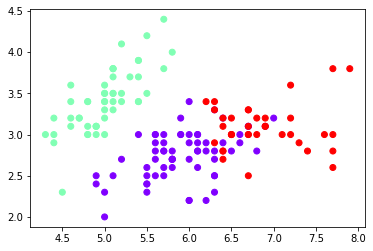

In [5]:
plt.scatter(features[:,0], features[:,1], c= hc_model.labels_, cmap='rainbow' )

其树状图的输出如下：

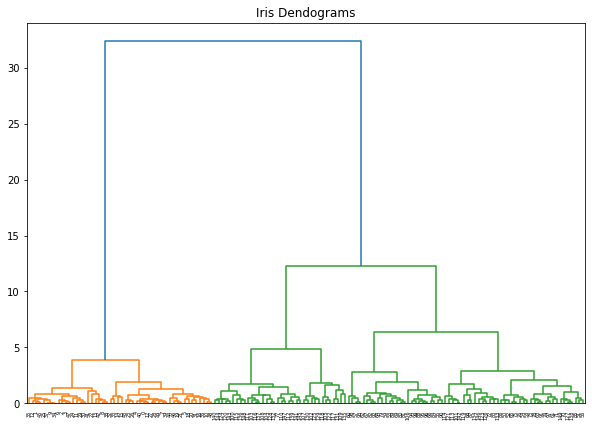

In [6]:
import scipy.cluster.hierarchy as shc
plt.figure(figsize=(10, 7))
plt.title("Iris Dendograms")
dend = shc.dendrogram(shc.linkage(features, method='ward'))
